<h5> Load the sealed OG test set and split into 50% new-validation / 50% blind-test

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Load the sealed OG 30% test set — untouched since Notebook 3
X_test_og = pd.read_csv('X_test_clean.csv')
y_test_og = pd.read_csv('y_test_clean.csv').squeeze()

print(f"OG test set shape: {X_test_og.shape}")
print(f"OG test set class distribution:\n{y_test_og.value_counts()}")

# Split 50:50, stratified, into a new-validation set and a final blind-test set
X_new_val, X_blind_test, y_new_val, y_blind_test = train_test_split(
    X_test_og, y_test_og, test_size=0.5, random_state=42, stratify=y_test_og
)

print(f"\nNew-validation shape: {X_new_val.shape}")
print(f"New-validation class distribution:\n{y_new_val.value_counts()}")

print(f"\nBlind-test shape: {X_blind_test.shape}")
print(f"Blind-test class distribution:\n{y_blind_test.value_counts()}")

OG test set shape: (7209, 50)
OG test set class distribution:
default payment next month
0    7010
1     199
Name: count, dtype: int64

New-validation shape: (3604, 50)
New-validation class distribution:
default payment next month
0    3505
1      99
Name: count, dtype: int64

Blind-test shape: (3605, 50)
Blind-test class distribution:
default payment next month
0    3505
1     100
Name: count, dtype: int64


<h5> Load the full outer-train (70%, imbalanced, no inner-split) and apply SMOTE directly

In [3]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

# Load the full 70% outer-train — original, imbalanced, no inner-train/inner-validation split
X_train_outer = pd.read_csv('X_train_clean.csv')
y_train_outer = pd.read_csv('y_train_clean.csv').squeeze()

print(f"Outer-train shape: {X_train_outer.shape}")
print(f"Outer-train class distribution:\n{y_train_outer.value_counts()}")

# Scale FIRST (fit on this full outer-train), same discipline as Dataset 3 notebook —
# SMOTE's neighbor-finding is distance-based, so scaling must happen before resampling
scaler = StandardScaler()
X_train_outer_scaled = pd.DataFrame(
    scaler.fit_transform(X_train_outer),
    columns=X_train_outer.columns,
    index=X_train_outer.index
)

# Apply SMOTE to the full, scaled outer-train
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_outer_scaled, y_train_outer)

print(f"\nBalanced train (post-SMOTE) shape: {X_train_balanced.shape}")
print(f"Balanced train class distribution:\n{pd.Series(y_train_balanced).value_counts()}")

Outer-train shape: (16819, 50)
Outer-train class distribution:
default payment next month
0    16354
1      465
Name: count, dtype: int64

Balanced train (post-SMOTE) shape: (32708, 50)
Balanced train class distribution:
default payment next month
0    16354
1    16354
Name: count, dtype: int64


<h5> Reusable Evaluate function

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score,
                              precision_score, recall_score, f1_score,
                              roc_auc_score, average_precision_score,
                              roc_curve, precision_recall_curve)

def evaluate_model(model, X_train, y_train, X_val, y_val, model_name):
    y_train_pred = model.predict(X_train)
    y_val_pred = model.predict(X_val)

    y_train_proba = model.predict_proba(X_train)[:, 1]
    y_val_proba = model.predict_proba(X_val)[:, 1]

    print(f"===== {model_name} =====")
    print("\n--- Training Set Performance (balanced) ---")
    print(classification_report(y_train, y_train_pred, digits=3))
    print(f"Training Accuracy: {accuracy_score(y_train, y_train_pred):.4f}")

    print("\n--- Validation Performance (real, imbalanced) ---")
    print(classification_report(y_val, y_val_pred, digits=3))
    print(f"Validation Accuracy: {accuracy_score(y_val, y_val_pred):.4f}")

    roc_auc_train = roc_auc_score(y_train, y_train_proba)
    roc_auc_val = roc_auc_score(y_val, y_val_proba)
    pr_auc_train = average_precision_score(y_train, y_train_proba)
    pr_auc_val = average_precision_score(y_val, y_val_proba)

    print(f"\nTrain ROC-AUC: {roc_auc_train:.4f} | Validation ROC-AUC: {roc_auc_val:.4f}")
    print(f"Train PR-AUC:  {pr_auc_train:.4f} | Validation PR-AUC:  {pr_auc_val:.4f}")

    cm = confusion_matrix(y_val, y_val_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'{model_name} - Confusion Matrix (Validation)')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

    fpr, tpr, _ = roc_curve(y_val, y_val_proba)
    plt.figure(figsize=(8,6))
    plt.plot([0,1], [0,1], linestyle='--', color='gray', label='No Skill')
    plt.plot(fpr, tpr, color='orange', label=f'{model_name} (AUC = {roc_auc_val:.3f})')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'{model_name} - ROC Curve (Validation)')
    plt.legend()
    plt.show()

    precision, recall, _ = precision_recall_curve(y_val, y_val_proba)
    no_skill = y_val.sum() / len(y_val)
    plt.figure(figsize=(8,6))
    plt.plot([0,1], [no_skill, no_skill], linestyle='--', color='gray', label='No Skill')
    plt.plot(recall, precision, color='orange', label=f'{model_name} (AUC = {pr_auc_val:.3f})')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(f'{model_name} - Precision-Recall Curve (Validation)')
    plt.legend()
    plt.show()

    return {'model_name': model_name,
            'accuracy_train': accuracy_score(y_train, y_train_pred), 'accuracy_val': accuracy_score(y_val, y_val_pred),
            'precision_val': precision_score(y_val, y_val_pred), 'recall_val': recall_score(y_val, y_val_pred),
            'f1_val': f1_score(y_val, y_val_pred),
            'roc_auc_train': roc_auc_train, 'roc_auc_val': roc_auc_val,
            'pr_auc_train': pr_auc_train, 'pr_auc_val': pr_auc_val}

<h5> Fit a raw XGBoost model on the new SMOTE-balanced train data

In [5]:
from xgboost import XGBClassifier

xgb_final = XGBClassifier(random_state=42, n_jobs=-1)
xgb_final.fit(X_train_balanced, y_train_balanced)

print("XGBoost fitted on full SMOTE-balanced outer-train.")
print(f"Training data shape: {X_train_balanced.shape}")

XGBoost fitted on full SMOTE-balanced outer-train.
Training data shape: (32708, 50)


<h5> See the actual resolved parameter values XGBoost used internally

In [6]:
import json

config = json.loads(xgb_final.get_booster().save_config())
tree_params = config['learner']['gradient_booster']['tree_train_param']

for param, value in tree_params.items():
    print(f"{param}: {value}")

alpha: 0
colsample_bylevel: 1
colsample_bynode: 1
colsample_bytree: 1
eta: 0.300000012
gamma: 0
grow_policy: depthwise
interaction_constraints: 
lambda: 1
learning_rate: 0.300000012
max_bin: 256
max_cat_threshold: 64
max_cat_to_onehot: 4
max_delta_step: 0
max_depth: 6
max_leaves: 0
min_child_weight: 1
min_split_loss: 0
monotone_constraints: ()
refresh_leaf: 1
reg_alpha: 0
reg_lambda: 1
sampling_method: uniform
sparse_threshold: 0.20000000000000001
subsample: 1


In [7]:
import json

config = json.loads(xgb_final.get_booster().save_config())
print(json.dumps(config['learner'], indent=2))

{
  "generic_param": {
    "device": "cpu",
    "fail_on_invalid_gpu_id": "0",
    "n_jobs": "-1",
    "nthread": "-1",
    "random_state": "42",
    "seed": "42",
    "seed_per_iteration": "0",
    "validate_parameters": "1"
  },
  "gradient_booster": {
    "gbtree_model_param": {
      "num_parallel_tree": "1",
      "num_trees": "100"
    },
    "gbtree_train_param": {
      "process_type": "default",
      "tree_method": "auto",
      "updater": "grow_quantile_histmaker",
      "updater_seq": "grow_quantile_histmaker"
    },
    "name": "gbtree",
    "specified_updater": false,
    "tree_train_param": {
      "alpha": "0",
      "colsample_bylevel": "1",
      "colsample_bynode": "1",
      "colsample_bytree": "1",
      "eta": "0.300000012",
      "gamma": "0",
      "grow_policy": "depthwise",
      "interaction_constraints": "",
      "lambda": "1",
      "learning_rate": "0.300000012",
      "max_bin": "256",
      "max_cat_threshold": "64",
      "max_cat_to_onehot": "4",
    

<h5> Feature Importance — XGBoost's built-in importance (on the SMOTE-balanced train data)

PAY_0                            0.164847
MARRIAGE_single                  0.128585
EDUCATION_university             0.108908
SEX_female                       0.082451
PAY_3                            0.044910
SEX_male                         0.036025
PAY_6                            0.035221
PAY_4                            0.034897
PAY_2                            0.030920
PAY_5                            0.029783
SEX_UNKNOWN                      0.023205
BILL_AMT1                        0.021938
EDUCATION_graduate school        0.020765
EDUCATION_high school diploma    0.020603
JOB_TYPE_12.0                    0.015629
JOB_TYPE_13.0                    0.014304
MARRIAGE_married                 0.013461
JOB_TYPE_11.0                    0.013133
MARRIAGE_UNKNOWN                 0.012818
LIMIT_BAL                        0.012229
JOB_TYPE_10.0                    0.009426
JOB_TYPE_6.0                     0.009077
JOB_TYPE_1.0                     0.009059
PAY_AMT1                         0

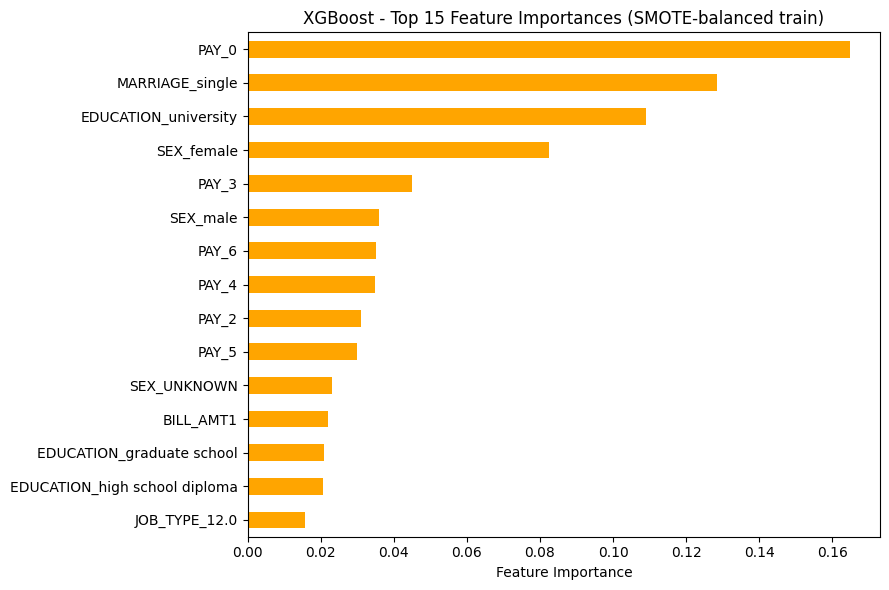

In [8]:
import matplotlib.pyplot as plt
import pandas as pd

importances = pd.Series(xgb_final.feature_importances_, index=X_train_balanced.columns)
importances_sorted = importances.sort_values(ascending=False)

pd.set_option('display.max_rows', None)
print(importances_sorted)

plt.figure(figsize=(9, 6))
importances_sorted.head(15).sort_values().plot(kind='barh', color='orange')
plt.xlabel('Feature Importance')
plt.title('XGBoost - Top 15 Feature Importances (SMOTE-balanced train)')
plt.tight_layout()
plt.show()

<h5> SHAP Analysis — XGBoost, on new-validation non-defaulters only (y=0)

c:\SID\Anaconda3\envs\apoorva_ml_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Number of real non-defaulters in new-validation: 3505


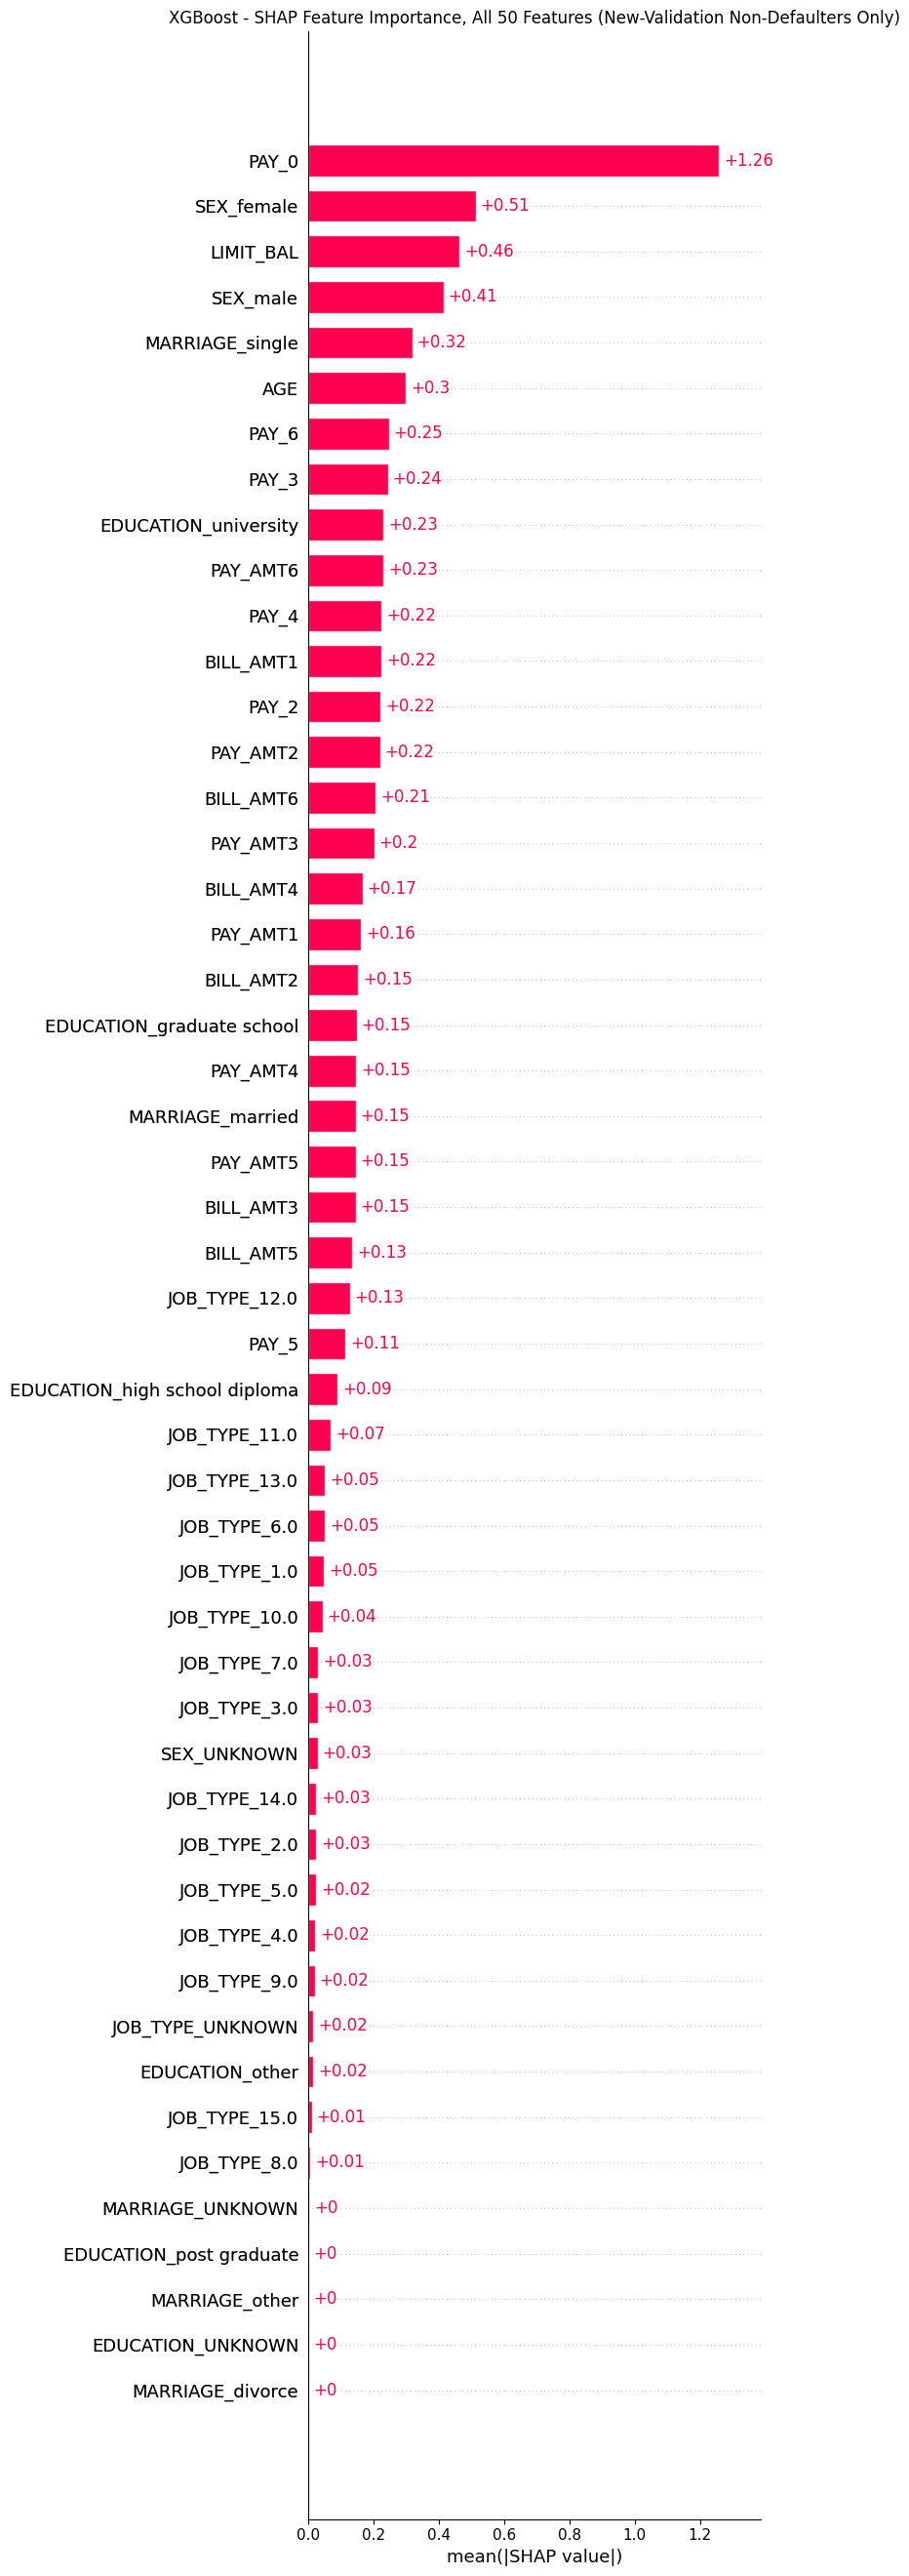

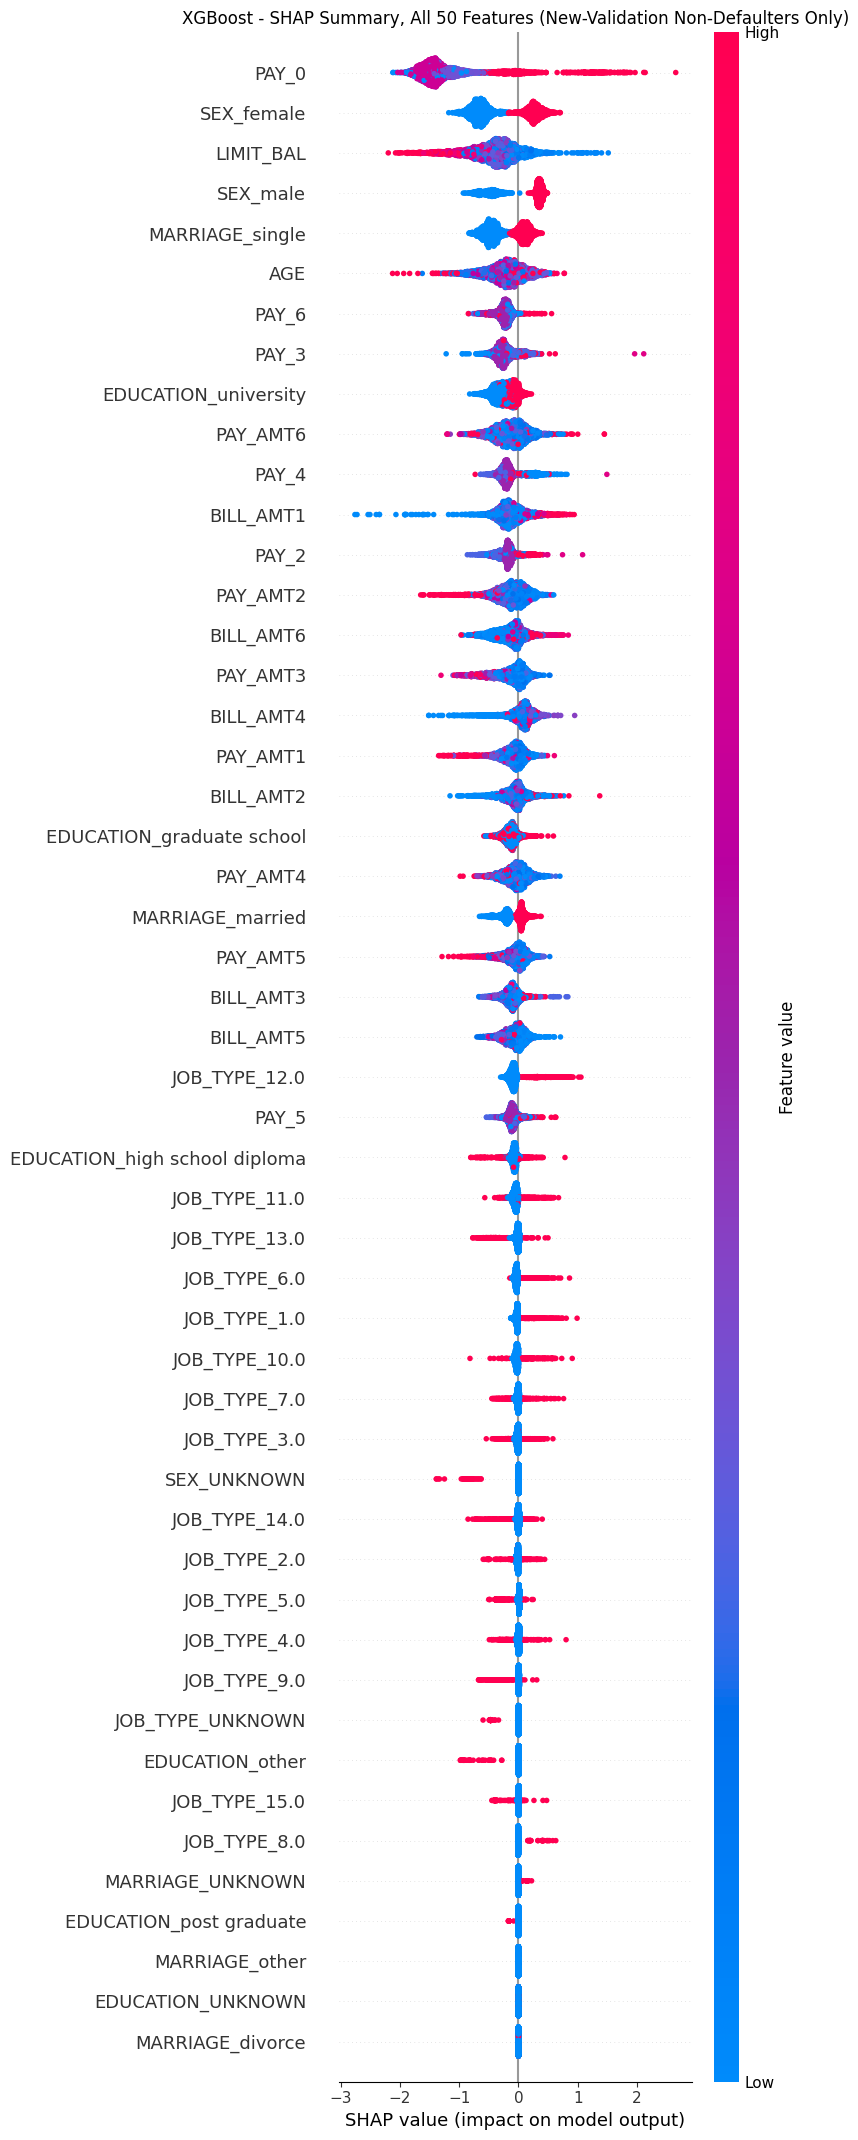

In [9]:
import shap
import matplotlib.pyplot as plt

X_new_val_scaled = pd.DataFrame(
    scaler.transform(X_new_val),
    columns=X_new_val.columns,
    index=X_new_val.index
)

X_new_val_non_defaulters = X_new_val_scaled[y_new_val == 0]
print(f"Number of real non-defaulters in new-validation: {X_new_val_non_defaulters.shape[0]}")

explainer = shap.TreeExplainer(xgb_final)
shap_values = explainer(X_new_val_non_defaulters)

if len(shap_values.shape) == 3:
    shap_values = shap_values[:, :, 1]

shap.plots.bar(shap_values, max_display=50, show=False)
plt.title('XGBoost - SHAP Feature Importance, All 50 Features (New-Validation Non-Defaulters Only)')
plt.tight_layout()
plt.show()

shap.plots.beeswarm(shap_values, max_display=50, show=False)
plt.title('XGBoost - SHAP Summary, All 50 Features (New-Validation Non-Defaulters Only)')
plt.tight_layout()
plt.show()

<h5> Create a reduced train dataset with only these top 28 SHAP-selected features

In [10]:
# selected_features = [
#     'PAY_0', 'SEX_female', 'SEX_male', 'LIMIT_BAL', 'MARRIAGE_single', 'AGE',
#     'PAY_6', 'PAY_2', 'BILL_AMT1', 'PAY_4', 'PAY_3', 'PAY_AMT6', 'BILL_AMT6',
#     'EDUCATION_university', 'PAY_AMT2', 'JOB_TYPE_12.0', 'BILL_AMT4', 'PAY_AMT4',
#     'MARRIAGE_married', 'BILL_AMT2', 'EDUCATION_graduate school', 'PAY_AMT1',
#     'BILL_AMT5', 'PAY_AMT3', 'BILL_AMT3', 'PAY_AMT5', 'PAY_5',
#     'EDUCATION_high school diploma'
# ]

selected_features = [
    "PAY_0",
    "MARRIAGE_single",
    "EDUCATION_university",
    "SEX_female",
    "PAY_3",
    "SEX_male",
    "PAY_6",
    "PAY_4",
    "PAY_2",
    "PAY_5",
    "SEX_UNKNOWN",
    "BILL_AMT1",
    "EDUCATION_graduate school",
    "EDUCATION_high school diploma"
]

print(f"Number of selected features: {len(selected_features)}")

# Reduced training set (from the SMOTE-balanced full outer-train)
X_train_selected = X_train_balanced[selected_features]

print(f"Reduced train shape: {X_train_selected.shape}")

Number of selected features: 14
Reduced train shape: (32708, 14)


<h5> Evaluate this raw model

===== XGBoost (Final, SMOTE, Full Outer-Train) =====

--- Training Set Performance (balanced) ---
              precision    recall  f1-score   support

           0      0.991     1.000     0.995     16354
           1      1.000     0.991     0.995     16354

    accuracy                          0.995     32708
   macro avg      0.995     0.995     0.995     32708
weighted avg      0.995     0.995     0.995     32708

Training Accuracy: 0.9952

--- Validation Performance (real, imbalanced) ---
              precision    recall  f1-score   support

           0      0.975     0.995     0.984      3505
           1      0.296     0.081     0.127        99

    accuracy                          0.969      3604
   macro avg      0.635     0.538     0.556      3604
weighted avg      0.956     0.969     0.961      3604

Validation Accuracy: 0.9695

Train ROC-AUC: 0.9999 | Validation ROC-AUC: 0.7000
Train PR-AUC:  0.9999 | Validation PR-AUC:  0.0975


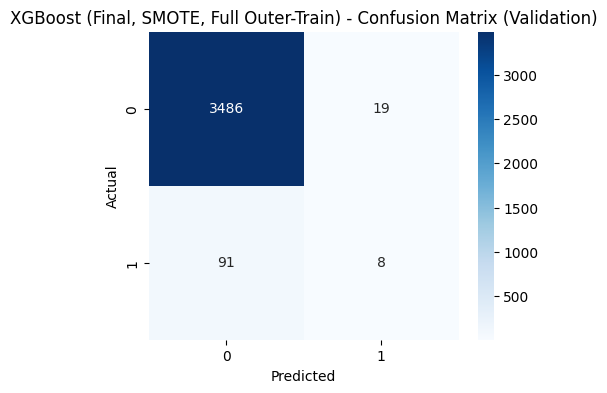

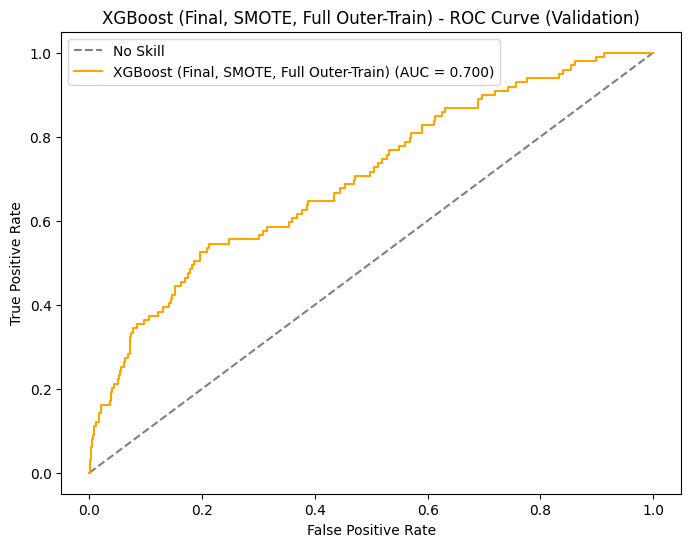

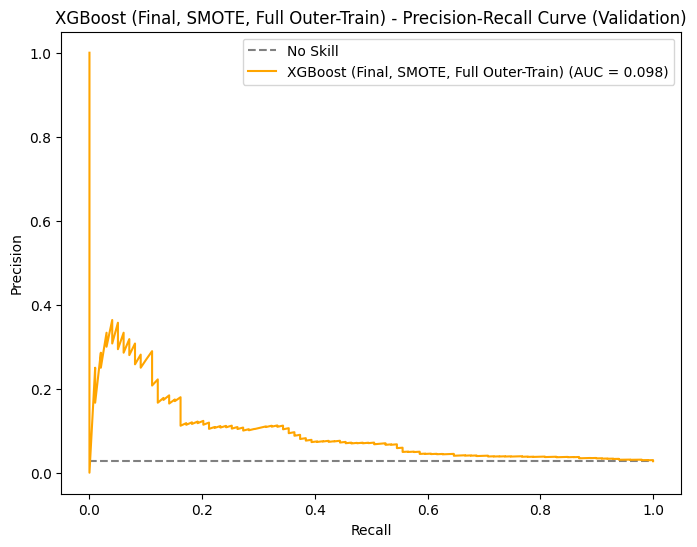

In [11]:
xgb_final_results = evaluate_model(xgb_final, X_train_balanced, y_train_balanced, X_new_val_scaled, y_new_val, "XGBoost (Final, SMOTE, Full Outer-Train)")

<h5> Hyperparameter tuning — XGBoost on the full SMOTE-balanced train data

In [12]:
from sklearn.model_selection import RandomizedSearchCV
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

# Reduced, RAW (unresampled) training data with your 28 selected features
X_train_outer_selected = X_train_outer_scaled[selected_features]

pipe = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('xgb', XGBClassifier(random_state=42, n_jobs=-1))
])

xgb_params = {
    # SMOTE ratio: how much to balance minority class relative to majority
    # 1.0 = full 1:1 balance (what you used before), lower = partial balance
    'smote__sampling_strategy': [0.2, 0.3, 0.5, 0.7, 1.0],

    # XGBoost's own cost-sensitive weighting — higher values push it to
    # care more about minority-class errors. Roughly 3505/99 ≈ 35 is "full" imbalance ratio,
    # so we search a range below and around that rather than assuming full correction is best
    'xgb__scale_pos_weight': [1, 3, 5, 10, 20],

    'xgb__max_depth': [3, 4, 5, 6],
    'xgb__learning_rate': [0.01, 0.05, 0.1],
    'xgb__n_estimators': [100, 200, 300, 500],
    'xgb__min_child_weight': [1, 3, 5],
    'xgb__subsample': [0.7, 0.8, 1.0],
    'xgb__colsample_bytree': [0.7, 0.8, 1.0],
    'xgb__reg_alpha': [0, 0.1, 1],
    'xgb__reg_lambda': [1, 2, 5],
    'xgb__gamma': [0, 0.1, 0.5, 1],
}

xgb_search_v2 = RandomizedSearchCV(
    pipe,
    param_distributions=xgb_params,
    n_iter=60, cv=5, scoring='f1',
    random_state=42, n_jobs=-1, verbose=1
)

xgb_search_v2.fit(X_train_outer_selected, y_train_outer)

print(f"Best params: {xgb_search_v2.best_params_}")
print(f"Best CV F1 score: {xgb_search_v2.best_score_:.4f}")

xgb_tuned_v2 = xgb_search_v2.best_estimator_

Fitting 5 folds for each of 60 candidates, totalling 300 fits
Best params: {'xgb__subsample': 1.0, 'xgb__scale_pos_weight': 1, 'xgb__reg_lambda': 1, 'xgb__reg_alpha': 0, 'xgb__n_estimators': 100, 'xgb__min_child_weight': 5, 'xgb__max_depth': 4, 'xgb__learning_rate': 0.01, 'xgb__gamma': 0.5, 'xgb__colsample_bytree': 1.0, 'smote__sampling_strategy': 0.7}
Best CV F1 score: 0.2587


In [13]:
X_new_val_selected=X_new_val_scaled[selected_features].copy()

===== XGBoost (SMOTE + scale_pos_weight, Tuned v2) =====

--- Training Set Performance (balanced) ---
              precision    recall  f1-score   support

           0      0.981     0.965     0.973     16354
           1      0.222     0.353     0.273       465

    accuracy                          0.948     16819
   macro avg      0.602     0.659     0.623     16819
weighted avg      0.960     0.948     0.954     16819

Training Accuracy: 0.9480

--- Validation Performance (real, imbalanced) ---
              precision    recall  f1-score   support

           0      0.978     0.962     0.970      3505
           1      0.146     0.232     0.180        99

    accuracy                          0.942      3604
   macro avg      0.562     0.597     0.575      3604
weighted avg      0.955     0.942     0.948      3604

Validation Accuracy: 0.9417

Train ROC-AUC: 0.7893 | Validation ROC-AUC: 0.6784
Train PR-AUC:  0.1718 | Validation PR-AUC:  0.0908


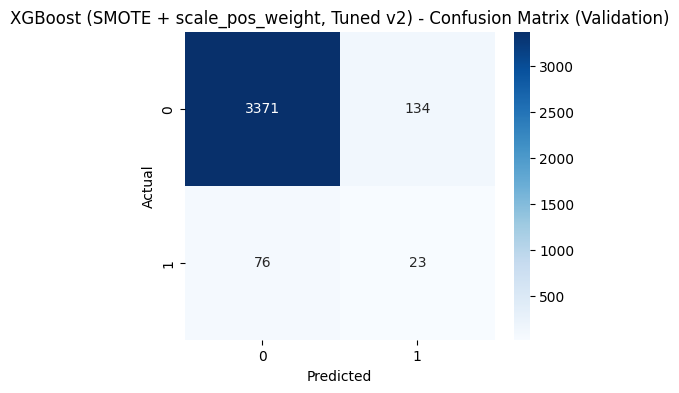

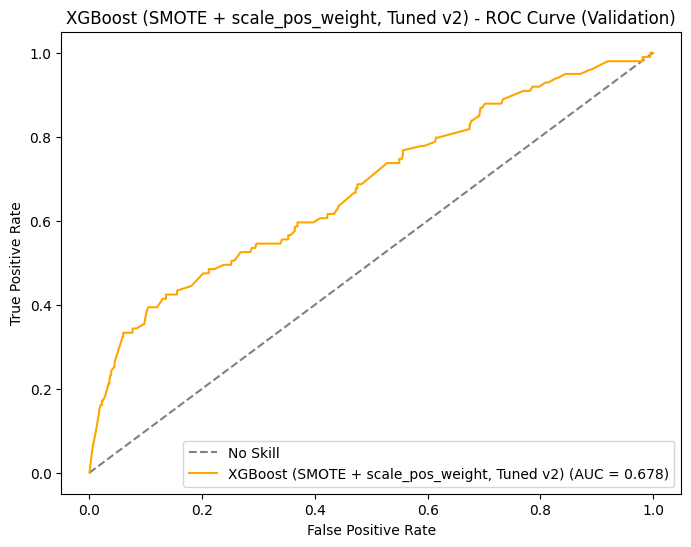

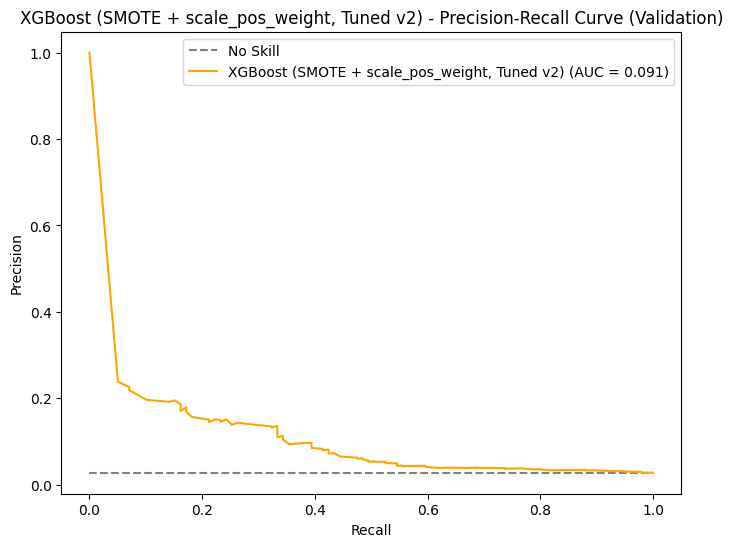

In [14]:
xgb_tuned_v2_results = evaluate_model(
    xgb_tuned_v2, X_train_outer_selected, y_train_outer,
    X_new_val_selected, y_new_val, "XGBoost (SMOTE + scale_pos_weight, Tuned v2)"
)

In [15]:
y_proba_2 = xgb_tuned_v2.predict_proba(X_new_val_selected)[:,0]

In [16]:
y_proba_2

array([0.7343724 , 0.73604834, 0.7347275 , ..., 0.35260957, 0.7532485 ,
       0.7308961 ], shape=(3604,), dtype=float32)

<h5> Let's check on blind test

In [17]:
# X_Blind_selected=X_blind_test[selected_features].copy()
X_blind_test_scaled = pd.DataFrame(
    scaler.transform(X_blind_test),
    columns=X_blind_test.columns,
    index=X_blind_test.index
)

X_Blind_selected = X_blind_test_scaled[selected_features].copy()

<h5> probability that this row in blind test belongs to 0 - prob_non_default and 1 - prob_default

In [18]:
# Compute both probability columns from the clean, feature-only dataframe
proba_2 = xgb_tuned_v2.predict_proba(X_Blind_selected)  # shape (n_rows, 2)

X_Blind_selected['prob_non_default'] = proba_2[:, 0]

In [19]:
X_Blind_selected.head()

,PAY_0,MARRIAGE_single,EDUCATION_university,SEX_female,PAY_3,SEX_male,PAY_6,PAY_4,PAY_2,PAY_5,SEX_UNKNOWN,BILL_AMT1,EDUCATION_graduate school,EDUCATION_high school diploma,prob_non_default
1480,1.215468,-0.879755,1.106279,-0.773308,-0.677387,0.820995,0.373262,0.314956,-1.653950,0.36044,-0.171031,-0.714467,-0.734312,-0.427225,0.594742
1079,0.182056,1.136680,-0.903931,1.293146,0.271553,-1.218035,0.373262,0.314956,0.257531,0.36044,-0.171031,1.620103,1.361818,-0.427225,0.721056
4552,0.182056,-0.879755,-0.903931,1.293146,0.271553,-1.218035,0.373262,0.314956,0.257531,0.36044,-0.171031,-0.490750,1.361818,-0.427225,0.719396
6617,0.182056,-0.879755,-0.903931,1.293146,0.271553,-1.218035,0.373262,0.314956,0.257531,0.36044,-0.171031,-0.270204,1.361818,-0.427225,0.719396
1509,0.182056,1.136680,-0.903931,-0.773308,2.169432,0.820995,3.347630,0.314956,0.257531,0.36044,-0.171031,-0.559802,-0.734312,2.340687,0.659822


<h5> Binning strategy

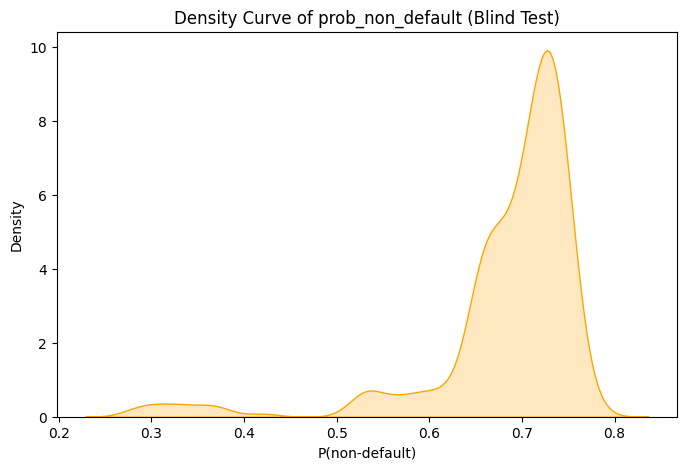

In [20]:
import seaborn as sns

plt.figure(figsize=(8,5))
sns.kdeplot(X_Blind_selected['prob_non_default'], color='orange', fill=True)
plt.xlabel('P(non-default)')
plt.ylabel('Density')
plt.title('Density Curve of prob_non_default (Blind Test)')
plt.show()

In [21]:
# import numpy as np
# from scipy.stats import gaussian_kde
# from scipy.signal import argrelextrema

# # Fit KDE on the corrected prob_non_default values
# data = X_Blind_selected['prob_non_default'].dropna().values
# kde = gaussian_kde(data)

# # Evaluate KDE over a fine grid spanning the data range
# x_grid = np.linspace(data.min(), data.max(), 2000)
# density = kde(x_grid)

# # Find local minima (troughs) and maxima (peaks)
# minima_idx = argrelextrema(density, np.less)[0]
# maxima_idx = argrelextrema(density, np.greater)[0]

# troughs = x_grid[minima_idx]
# peaks = x_grid[maxima_idx]

# print("Peaks (local maxima):", peaks)
# print("Troughs (local minima):", troughs)
# print("\nData min:", data.min(), "| Data max:", data.max())

In [22]:
# import numpy as np
# import pandas as pd

# data = X_Blind_selected['prob_non_default'].dropna()

# troughs = [0.4671798, 0.5653241]
# edges = [float(data.min())] + troughs + [float(data.max())]

# # We have 3 natural bins, need 2 more splits to reach 5 total bins
# n_splits_needed = 5 - len(edges) + 1  # = 2

# new_edges = edges.copy()
# for _ in range(n_splits_needed):
#     widths = np.diff(new_edges)
#     widest_idx = np.argmax(widths)
#     lo, hi = new_edges[widest_idx], new_edges[widest_idx + 1]
#     mask = (data >= lo) & (data <= hi)
#     median_split = data[mask].median()
#     new_edges = sorted(new_edges + [median_split])

# final_edges = new_edges
# print("Final bin edges:", final_edges)

# bin_labels = [
#     'Very High Risk',
#     'High Risk',
#     'Moderate Risk',
#     'Low Risk',
#     'Very Low Risk'
# ]

# X_Blind_selected['repayment_likelihood_bin'] = pd.cut(
#     data, bins=final_edges, labels=bin_labels, include_lowest=True
# )

# X_Blind_selected['repayment_likelihood_bin'].value_counts().sort_index()

In [23]:
import pandas as pd

bin_edges = [0.28, 0.33, 0.47, 0.57, 0.71, 0.79]
# bin_labels = [
#     'Very Low',
#     'Low',
#     'Moderate',
#     'High',
#     'Very High'
# ]

bin_labels = [
    'Very High Risk',
    'High Risk',
    'Moderate Risk',
    'Low Risk',
    'Very Low Risk'
]

X_Blind_selected['repayment_likelihood_bin'] = pd.cut(
    X_Blind_selected['prob_non_default'],
    bins=bin_edges,
    labels=bin_labels,
    include_lowest=True
)

# Check counts per bin
X_Blind_selected['repayment_likelihood_bin'].value_counts().sort_index()

repayment_likelihood_bin
Very High Risk      57
High Risk           81
Moderate Risk      156
Low Risk          1449
Very Low Risk     1848
Name: count, dtype: int64

In [24]:
X_Blind_selected.head()

,PAY_0,MARRIAGE_single,EDUCATION_university,SEX_female,PAY_3,SEX_male,PAY_6,PAY_4,PAY_2,PAY_5,SEX_UNKNOWN,BILL_AMT1,EDUCATION_graduate school,EDUCATION_high school diploma,prob_non_default,repayment_likelihood_bin
1480,1.215468,-0.879755,1.106279,-0.773308,-0.677387,0.820995,0.373262,0.314956,-1.653950,0.36044,-0.171031,-0.714467,-0.734312,-0.427225,0.594742,Low Risk
1079,0.182056,1.136680,-0.903931,1.293146,0.271553,-1.218035,0.373262,0.314956,0.257531,0.36044,-0.171031,1.620103,1.361818,-0.427225,0.721056,Very Low Risk
4552,0.182056,-0.879755,-0.903931,1.293146,0.271553,-1.218035,0.373262,0.314956,0.257531,0.36044,-0.171031,-0.490750,1.361818,-0.427225,0.719396,Very Low Risk
6617,0.182056,-0.879755,-0.903931,1.293146,0.271553,-1.218035,0.373262,0.314956,0.257531,0.36044,-0.171031,-0.270204,1.361818,-0.427225,0.719396,Very Low Risk
1509,0.182056,1.136680,-0.903931,-0.773308,2.169432,0.820995,3.347630,0.314956,0.257531,0.36044,-0.171031,-0.559802,-0.734312,2.340687,0.659822,Low Risk


<h5> Bar chart

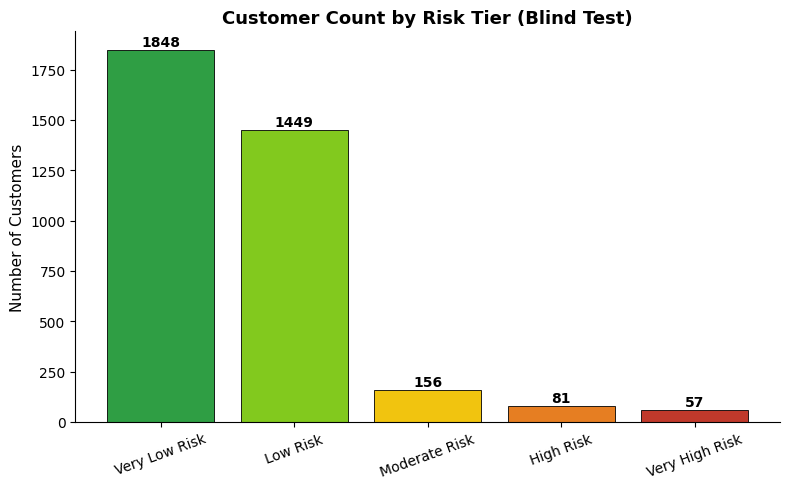

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

order = ['Very Low Risk', 'Low Risk', 'Moderate Risk', 'High Risk', 'Very High Risk']
counts = X_Blind_selected['repayment_likelihood_bin'].value_counts().reindex(order)

colors = ['#2f9e44', '#82c91e', '#f1c40f', '#e67e22', '#c0392b']  # green -> red gradient

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(order, counts, color=colors, edgecolor='black', linewidth=0.6)

# value labels on top of each bar
for bar, val in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
             str(val), ha='center', fontsize=10, fontweight='bold')

ax.set_ylabel('Number of Customers', fontsize=11)
ax.set_title('Customer Count by Risk Tier (Blind Test)', fontsize=13, fontweight='bold')
ax.set_xlabel('')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

<h5> let's evaluate on blind test

===== XGBoost (SMOTE + scale_pos_weight, Tuned v2) - BLIND TEST =====

--- Blind Test Performance ---
              precision    recall  f1-score   support

           0      0.979     0.965     0.972      3505
           1      0.191     0.290     0.230       100

    accuracy                          0.946      3605
   macro avg      0.585     0.627     0.601      3605
weighted avg      0.958     0.946     0.952      3605

Blind Test Accuracy: 0.9462

Blind Test ROC-AUC: 0.7653
Blind Test PR-AUC:  0.1331


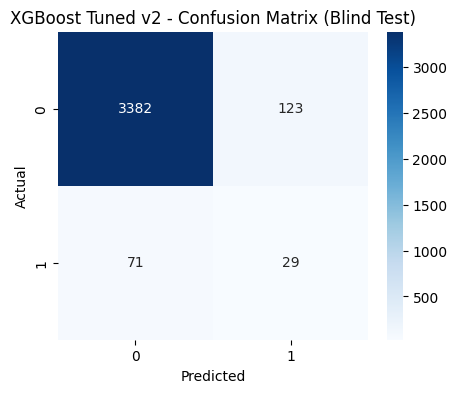

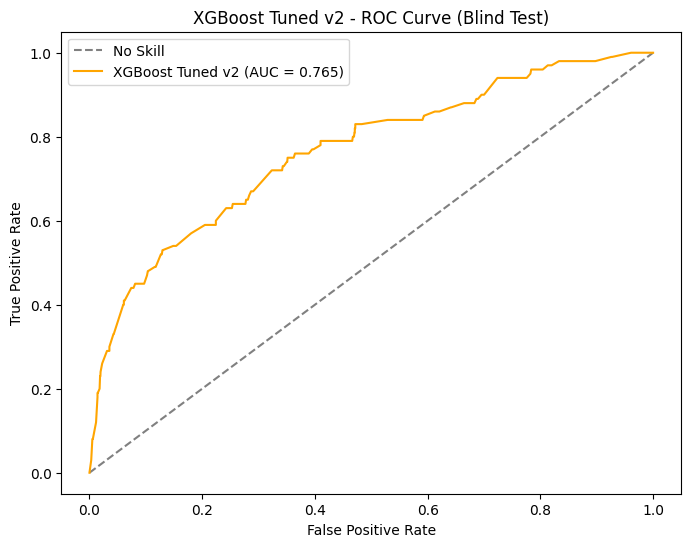

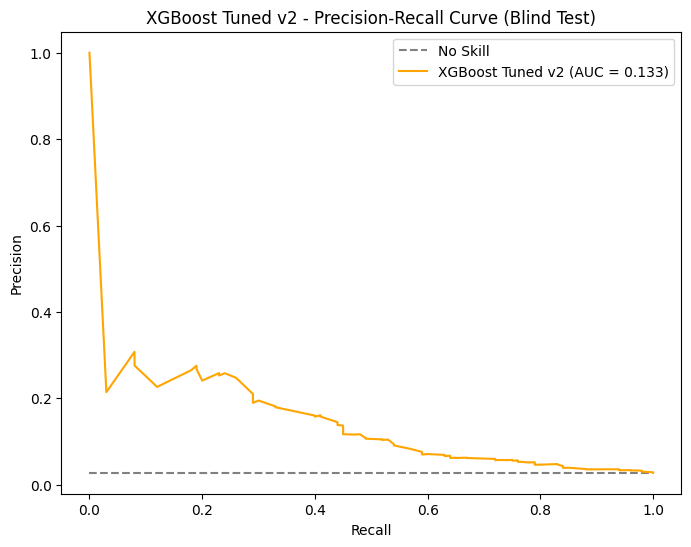

{'model_name': 'XGBoost (SMOTE + scale_pos_weight, Tuned v2) - Blind Test',
 'accuracy_blind': 0.9461858529819694,
 'precision_blind': 0.19078947368421054,
 'recall_blind': 0.29,
 'f1_blind': 0.23015873015873015,
 'roc_auc_blind': 0.7653195435092726,
 'pr_auc_blind': 0.13314347009883787}

In [26]:
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score,
                              precision_score, recall_score, f1_score,
                              roc_auc_score, average_precision_score,
                              roc_curve, precision_recall_curve)
import matplotlib.pyplot as plt
import seaborn as sns

# Re-slice to features only, since X_Blind_selected now has extra columns
y_blind_pred = xgb_tuned_v2.predict(X_Blind_selected[selected_features])
y_blind_proba = xgb_tuned_v2.predict_proba(X_Blind_selected[selected_features])[:, 1]

print("===== XGBoost (SMOTE + scale_pos_weight, Tuned v2) - BLIND TEST =====")
print("\n--- Blind Test Performance ---")
print(classification_report(y_blind_test, y_blind_pred, digits=3))
print(f"Blind Test Accuracy: {accuracy_score(y_blind_test, y_blind_pred):.4f}")

roc_auc_blind = roc_auc_score(y_blind_test, y_blind_proba)
pr_auc_blind = average_precision_score(y_blind_test, y_blind_proba)
print(f"\nBlind Test ROC-AUC: {roc_auc_blind:.4f}")
print(f"Blind Test PR-AUC:  {pr_auc_blind:.4f}")

cm = confusion_matrix(y_blind_test, y_blind_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('XGBoost Tuned v2 - Confusion Matrix (Blind Test)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

fpr, tpr, _ = roc_curve(y_blind_test, y_blind_proba)
plt.figure(figsize=(8,6))
plt.plot([0,1], [0,1], linestyle='--', color='gray', label='No Skill')
plt.plot(fpr, tpr, color='orange', label=f'XGBoost Tuned v2 (AUC = {roc_auc_blind:.3f})')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('XGBoost Tuned v2 - ROC Curve (Blind Test)')
plt.legend()
plt.show()

precision, recall, _ = precision_recall_curve(y_blind_test, y_blind_proba)
no_skill = y_blind_test.sum() / len(y_blind_test)
plt.figure(figsize=(8,6))
plt.plot([0,1], [no_skill, no_skill], linestyle='--', color='gray', label='No Skill')
plt.plot(recall, precision, color='orange', label=f'XGBoost Tuned v2 (AUC = {pr_auc_blind:.3f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('XGBoost Tuned v2 - Precision-Recall Curve (Blind Test)')
plt.legend()
plt.show()

blind_test_results = {
    'model_name': 'XGBoost (SMOTE + scale_pos_weight, Tuned v2) - Blind Test',
    'accuracy_blind': accuracy_score(y_blind_test, y_blind_pred),
    'precision_blind': precision_score(y_blind_test, y_blind_pred),
    'recall_blind': recall_score(y_blind_test, y_blind_pred),
    'f1_blind': f1_score(y_blind_test, y_blind_pred),
    'roc_auc_blind': roc_auc_blind,
    'pr_auc_blind': pr_auc_blind
}

blind_test_results